# 🚀 Mini-Batch Gradient Descent — The Sweet Spot
### The Ultimate Compromise Between Batch GD and Stochastic GD

> **Goal of this notebook:** Following our complete guides on Batch Gradient Descent and Stochastic Gradient Descent (SGD), this notebook will introduce you to **Mini-Batch Gradient Descent**. This is the algorithm that powers almost all modern Deep Learning. You will learn the math behind it, how to implement it from scratch, how to visualize its path, and how to use `scikit-learn` to process mini-batches in a loop.

---

## 📑 Table of Contents

1. [The Goldilocks Problem: Why BGD and SGD aren't perfect](#part1)
2. [Introduction to Mini-Batch Gradient Descent](#part2)
3. [The Mathematics of Mini-Batch GD](#part3)
4. [Coding Mini-Batch GD From Scratch](#part4)
5. [Visualizing the Path: BGD vs SGD vs Mini-Batch](#part5)
6. [Animating the Convergence](#part6)
7. [Using `scikit-learn` for Mini-Batch Training (`partial_fit`)](#part7)
8. [Summary: Advantages and Disadvantages](#part8)



## ⚙️ Setup
Let's import our libraries and generate a synthetic dataset for testing.



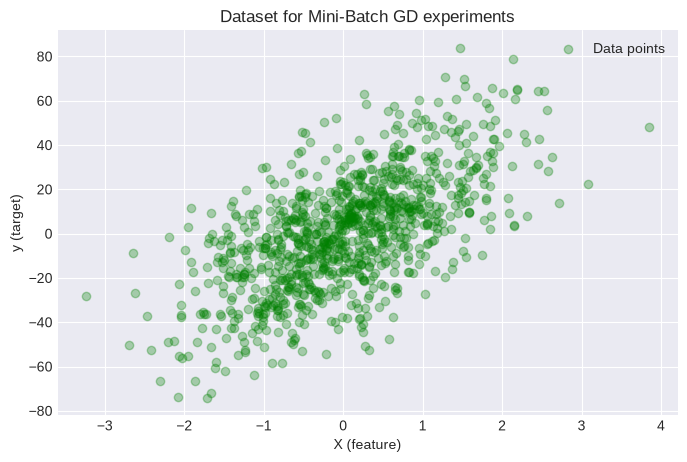

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.datasets import make_regression
from sklearn.linear_model import SGDRegressor
import time

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Generate a synthetic dataset
X, y = make_regression(n_samples=1000, n_features=1, noise=20, random_state=42)
y = y.reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='green', alpha=0.3, label='Data points')
plt.title("Dataset for Mini-Batch GD experiments")
plt.xlabel("X (feature)")
plt.ylabel("y (target)")
plt.legend()
plt.show()



<a id="part1"></a>
## 1. The Goldilocks Problem: Why BGD and SGD aren't perfect

We've explored two extremes in our optimization journey:

1. **Batch Gradient Descent (BGD):** Uses the **entire dataset** for one update.
   - *Pros:* Direct, stable path to the minimum. Utilizes vectorization perfectly.
   - *Cons:* Way too slow for large datasets. Cannot fit large datasets into RAM.

2. **Stochastic Gradient Descent (SGD):** Uses **1 single row** for one update.
   - *Pros:* Very fast iterations. Low memory requirement. Escapes local minima.
   - *Cons:* Extremely erratic/noisy path. Cannot fully utilize hardware vectorization (GPUs love matrix math, but SGD only feeds them one vector at a time).

**The Solution:** What if we take a small chunk of data at a time? Not 1 row, and not the whole dataset. Just a "Mini-Batch".



<a id="part2"></a>
## 2. Introduction to Mini-Batch Gradient Descent

Mini-Batch Gradient Descent splits the training dataset into small batches (e.g., 32, 64, 128, or 256 rows) and updates the model weights based on each batch.

- **Batch Size:** The number of training examples in one forward/backward pass. The higher the batch size, the more memory you need.
- **Epoch:** One complete pass through the *entire* training dataset. 
- **Iterations per epoch:** If you have 1,000 rows and a batch size of 50, you will have $1000 / 50 = 20$ iterations (updates) per epoch.

*Note: Batch sizes are usually powers of 2 (32, 64, 128, 256) because modern CPU/GPU architectures are optimized for processing arrays of these sizes.*



<a id="part3"></a>
## 3. The Mathematics of Mini-Batch GD

The update rule looks exactly like Batch GD, except the summation is only over the $k$ samples in the current mini-batch $B$.

Let $k$ be the batch size. For a specific batch $B$, the update rule is:

$$ \theta = \theta - \eta \cdot \frac{1}{k} \sum_{i \in B} \nabla L_i(\theta) $$

Where:
- $\theta$ are our parameters (slope, intercept).
- $\eta$ is the learning rate.
- $k$ is the size of our mini-batch.
- $\nabla L_i(\theta)$ is the gradient of the loss for a single example $i$.



<a id="part4"></a>
## 4. Coding Mini-Batch GD From Scratch

Let's implement Mini-Batch Gradient Descent for Linear Regression ($y = mx + b$).



In [2]:
class MiniBatchGDRegressor:
    def __init__(self, learning_rate=0.01, epochs=50, batch_size=32):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X_train, y_train):
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        n_samples = X_train.shape[0]
        
        for i in range(self.epochs):
            # Shuffle the data at the start of each epoch
            indices = np.random.permutation(n_samples)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]
            
            # Loop through the data in chunks of `batch_size`
            for j in range(0, n_samples, self.batch_size):
                # Slice the batch
                X_batch = X_train_shuffled[j : j + self.batch_size]
                y_batch = y_train_shuffled[j : j + self.batch_size]
                
                # Predict
                y_hat = np.dot(X_batch, self.coef_) + self.intercept_
                
                # Calculate gradients using vectorized operations over the batch
                intercept_der = -2 * np.mean(y_batch.flatten() - y_hat)
                coef_der = -2 * np.mean((y_batch.flatten() - y_hat) * X_batch.flatten())
                
                # Update
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)
                self.coef_ = self.coef_ - (self.lr * coef_der)
                
        return self

# Test Custom Mini-Batch GD
mbgd = MiniBatchGDRegressor(learning_rate=0.01, epochs=50, batch_size=32)

start_time = time.time()
mbgd.fit(X, y)
mbgd_time = time.time() - start_time

print(f"Mini-Batch GD Intercept: {mbgd.intercept_}")
print(f"Mini-Batch GD Coefficient: {mbgd.coef_}")
print(f"Time taken: {mbgd_time:.4f} seconds")



Mini-Batch GD Intercept: 0.1251701896929785
Mini-Batch GD Coefficient: [16.67747489]
Time taken: 0.0728 seconds


<a id="part5"></a>
## 5. Visualizing the Path: BGD vs SGD vs Mini-Batch

Let's simulate the path of all three algorithms on the loss contour to see exactly how Mini-Batch strikes a balance between BGD's smoothness and SGD's chaos.



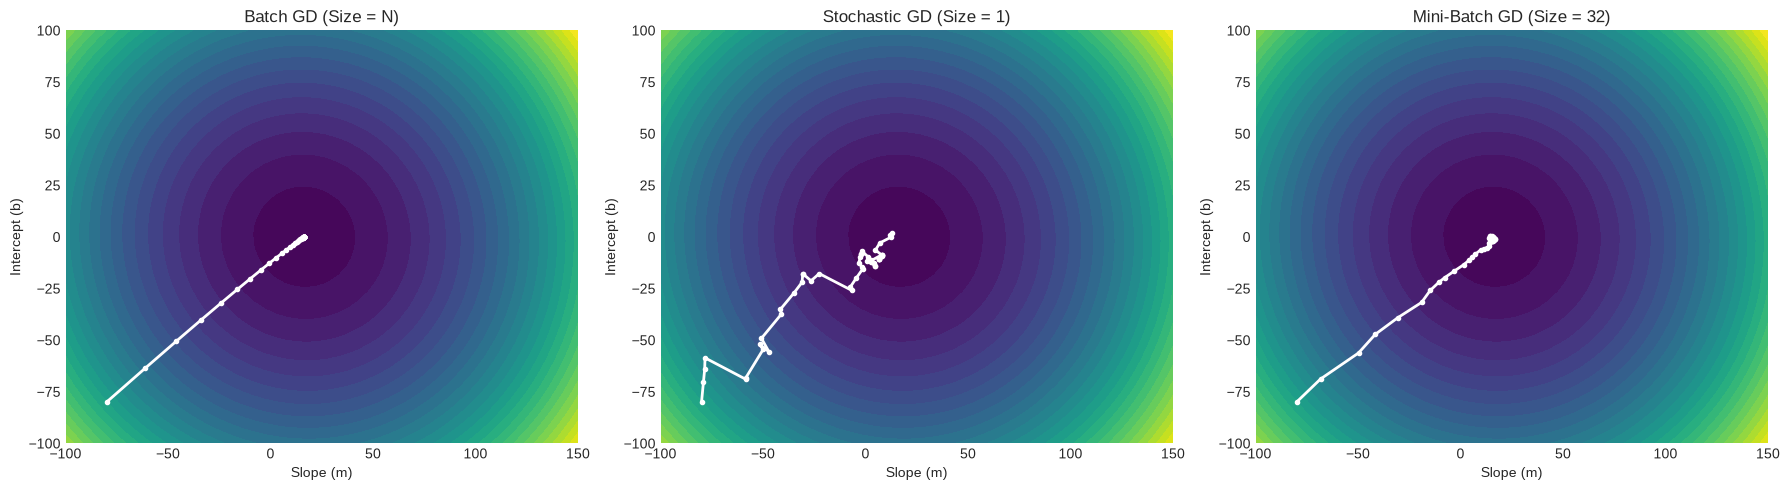

In [3]:
def simulate_paths(X, y):
    # Contour Setup
    m_vals = np.linspace(-100, 150, 50)
    b_vals = np.linspace(-100, 100, 50)
    M, B = np.meshgrid(m_vals, b_vals)
    Z = np.zeros_like(M)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            y_pred = M[i,j] * X.flatten() + B[i,j]
            Z[i,j] = np.mean((y.flatten() - y_pred)**2)
            
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Batch GD
    m_b, b_b = -80, -80
    lr_b = 0.1
    path_b_m, path_b_b = [m_b], [b_b]
    for _ in range(50):
        y_pred = m_b * X.flatten() + b_b
        m_b -= lr_b * (-2 * np.mean((y.flatten() - y_pred) * X.flatten()))
        b_b -= lr_b * (-2 * np.mean(y.flatten() - y_pred))
        path_b_m.append(m_b)
        path_b_b.append(b_b)
        
    axes[0].contourf(M, B, Z, levels=30, cmap='viridis')
    axes[0].plot(path_b_m, path_b_b, color='white', marker='.', linewidth=2)
    axes[0].set_title("Batch GD (Size = N)")
    
    # 2. Stochastic GD
    m_s, b_s = -80, -80
    lr_s = 0.05
    path_s_m, path_s_b = [m_s], [b_s]
    for _ in range(50):
        idx = np.random.randint(0, len(X))
        x_i = X[idx][0]
        y_i = y[idx][0]
        y_pred = m_s * x_i + b_s
        m_s -= lr_s * (-2 * (y_i - y_pred) * x_i)
        b_s -= lr_s * (-2 * (y_i - y_pred))
        path_s_m.append(m_s)
        path_s_b.append(b_s)
        
    axes[1].contourf(M, B, Z, levels=30, cmap='viridis')
    axes[1].plot(path_s_m, path_s_b, color='white', marker='.', linewidth=2)
    axes[1].set_title("Stochastic GD (Size = 1)")
    
    # 3. Mini-Batch GD
    m_mb, b_mb = -80, -80
    lr_mb = 0.08
    batch_size = 32
    path_mb_m, path_mb_b = [m_mb], [b_mb]
    
    for _ in range(50):
        indices = np.random.choice(len(X), batch_size, replace=False)
        X_batch = X[indices].flatten()
        y_batch = y[indices].flatten()
        y_pred = m_mb * X_batch + b_mb
        m_mb -= lr_mb * (-2 * np.mean((y_batch - y_pred) * X_batch))
        b_mb -= lr_mb * (-2 * np.mean(y_batch - y_pred))
        path_mb_m.append(m_mb)
        path_mb_b.append(b_mb)
        
    axes[2].contourf(M, B, Z, levels=30, cmap='viridis')
    axes[2].plot(path_mb_m, path_mb_b, color='white', marker='.', linewidth=2)
    axes[2].set_title(f"Mini-Batch GD (Size = {batch_size})")
    
    for ax in axes:
        ax.set_xlabel("Slope (m)")
        ax.set_ylabel("Intercept (b)")
        
    plt.tight_layout()
    plt.show()

simulate_paths(X, y)



<a id="part6"></a>
## 6. Animating the Convergence

Here's an animation to watch the Mini-Batch algorithm navigate the loss landscape. Notice how it's not as completely straight as Batch GD, but heavily dampens the wild noise of SGD.



In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

m_vals = np.linspace(-100, 150, 50)
b_vals = np.linspace(-100, 100, 50)
M, B = np.meshgrid(m_vals, b_vals)
Z = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        y_pred = M[i,j] * X.flatten() + B[i,j]
        Z[i,j] = np.mean((y.flatten() - y_pred)**2)

ax.contourf(M, B, Z, levels=30, cmap='viridis')
ax.set_title("Mini-Batch GD Animation (Batch Size = 32)")
ax.set_xlabel("Slope (m)")
ax.set_ylabel("Intercept (b)")

line, = ax.plot([], [], color='white', marker='.', markersize=5, linewidth=2)

m_mb, b_mb = -80, -80
lr_mb = 0.05
batch_size = 32
m_path_mb, b_path_mb = [m_mb], [b_mb]

# Precompute 100 steps
for _ in range(100):
    indices = np.random.choice(len(X), batch_size, replace=False)
    X_batch = X[indices].flatten()
    y_batch = y[indices].flatten()
    y_pred = m_mb * X_batch + b_mb
    m_mb -= lr_mb * (-2 * np.mean((y_batch - y_pred) * X_batch))
    b_mb -= lr_mb * (-2 * np.mean(y_batch - y_pred))
    m_path_mb.append(m_mb)
    b_path_mb.append(b_mb)

def init():
    line.set_data([], [])
    return line,

def animate(i):
    line.set_data(m_path_mb[:i], b_path_mb[:i])
    return line,

anim = FuncAnimation(fig, animate, init_func=init, frames=len(m_path_mb), interval=100, blit=True)

plt.close() # Prevent static plot from showing

# Display the animation inline
HTML(anim.to_jshtml())



<a id="part7"></a>
## 7. Using `scikit-learn` for Mini-Batch Training (`partial_fit`)

`scikit-learn`'s `SGDRegressor` doesn't explicitly have a `batch_size` parameter in its `.fit()` method. 

Instead, it provides a method called `.partial_fit()`. This allows us to manually feed data in batches to the model in a for-loop! This is incredibly useful for **Out-of-Core** learning (when your dataset is too huge to fit into RAM, you can load it from a CSV in chunks and pass each chunk to `partial_fit`).



In [5]:
# Initialize the SGD model
sgd_sk = SGDRegressor(penalty=None, eta0=0.01, learning_rate='constant', random_state=42)

epochs = 50
batch_size = 32
n_samples = X.shape[0]

start_time = time.time()

for epoch in range(epochs):
    # Shuffle indices manually for the epoch
    indices = np.random.permutation(n_samples)
    
    # Loop over the dataset in chunks
    for start_idx in range(0, n_samples, batch_size):
        # Extract the mini-batch
        batch_idx = indices[start_idx : start_idx + batch_size]
        X_batch = X[batch_idx]
        y_batch = y[batch_idx].flatten()
        
        # Train the model on just this batch!
        sgd_sk.partial_fit(X_batch, y_batch)

sk_time = time.time() - start_time

print(f"Sklearn Mini-Batch Intercept: {sgd_sk.intercept_[0]}")
print(f"Sklearn Mini-Batch Coefficient: {sgd_sk.coef_[0]}")
print(f"Time taken: {sk_time:.4f} seconds")



Sklearn Mini-Batch Intercept: -0.0512449400275371
Sklearn Mini-Batch Coefficient: 15.254752317758316
Time taken: 1.6453 seconds


<a id="part8"></a>
## 8. Summary: Advantages and Disadvantages

As per robust documentation (Wikipedia, GeeksforGeeks), Mini-Batch GD sits in the perfect middle ground.

### Advantages:
1. **Memory Efficiency:** Doesn't require loading the entire dataset into RAM, making out-of-core learning possible.
2. **Hardware Optimization:** Takes advantage of highly optimized matrix-math libraries (Vectorization) unlike strict SGD. GPUs parallelize the computations across the $k$ elements in the batch.
3. **Smoother Convergence than SGD:** By averaging the gradient over a batch, the variance is reduced, leading to a much more stable and directed descent than strict SGD.
4. **Escapes Local Minima:** Still contains enough noise (unlike BGD) to help escape local minima in non-convex loss functions (like Neural Networks).

### Disadvantages:
1. **Hyperparameter Tuning:** It introduces a new hyperparameter: the **batch size**. You have to experiment to find the optimal size (usually powers of 2 like 32, 64, 128).
2. **Not as smooth as BGD:** It will still slightly oscillate around the global minimum at the end, requiring a learning rate decay schedule to properly settle.

> **Final Note:** Mini-batch Gradient Descent is the **industry standard**. When people say they are training a model using "SGD", 99% of the time, they are actually referring to Mini-Batch SGD!

